In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Ensure we can import from 'core'
sys.path.append(os.getcwd()+'/..')

from src.environment import LigandEnvironment, NormalConcentration,LogNormalConcentration
from src.physics import Receptor
from objectives.loss import ExactInformationLoss

# Initialize the environment

In [3]:
# 1. SETUP
# ----------------------------------------------------------------
# A single receptor (homopentamer) and a single ligand family
n_units = 1
n_families = 1
k_sub = 5
batch_size = 2048 # Large batch for good histograms

device = "cpu" # CPU is fine for plotting

# A. Environment (Concentration ~ Normal(5, 1))
conc_model = LogNormalConcentration(n_families, init_mean=-6, init_scale=0.8)
env = LigandEnvironment(n_units, n_families, conc_model).to(device)
with torch.no_grad():
    # adjust sigma to make it narrow
    env.interaction_log_sigma.copy_(torch.tensor([[[-5.,-5.]]]))



## Sample concentrations and energies

In [4]:
with torch.no_grad():
    # Step 1: Sample
    energies, concs, _ = env.sample_batch(batch_size)
# Convert to numpy
c_data = concs.numpy()

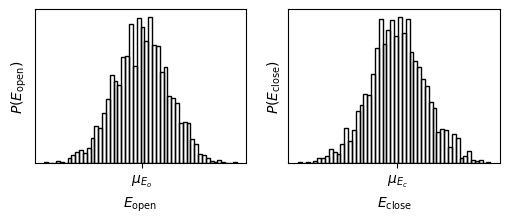

In [19]:
# 4. PLOTTING
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(2*3, 2))

# Panel A: Concentration Distribution
#bins = np.logspace(np.log10(c_data.min()), np.log10(c_data.max()), 50)
#axes[0].hist(c_data,bins=bins)
#axes[0].set_title(f"Ligand Concentration\n(Input)", fontsize=9)
#axes[0].set_xlabel("Concentration")
#axes[0].set_xscale('log')

# Panel B: Energy Difference Distribution (E_open - E_closed)
axes[0].hist(energies[:,0,0],fill=False,bins=50)
axes[0].set_xlabel(r"$E_\text{open}$")

axes[1].hist(energies[:,0,1],fill=False,bins=50)
axes[1].set_xlabel(r"$E_\text{close}$")

axes[0].set_yticks([])
axes[1].set_yticks([])
axes[0].set_xticks([np.mean(energies[:,0,0].numpy())],[r'$\mu_{E_o}$'])
axes[1].set_xticks([np.mean(energies[:,0,1].numpy())],[r'$\mu_{E_c}$'])
axes[0].set_ylabel(r'$P(E_\text{open})$')
axes[1].set_ylabel(r'$P(E_\text{close})$')

fig.savefig('energy_distrib.svg',transparent=True,bbox_inches='tight')

In [11]:
np.mean(energies[:,0,0].numpy())

-12.63456

A good channel should have a dissociation rate larger in the close than open state, ie binding promote opening. With the dissociation rate $K_i = \exp(\beta \Delta E_i)$
$$
K_c > K_o \Rightarrow E_c > E_o
$$
The half max concentration is :
$$
Ec_{50}^l = \prod_{u=1}^{k_\text{sub}} e^{\epsilon_u} K_o^{(u,l)} = \prod_{u=1}^{k_\text{sub}} \tilde{K}_o^{(u,l)} = \exp\left( \sum_{u=1}^{k_\text{sub}} \Delta E_o^{(u,l)}\right)
$$
let us check that the initial value of the energies match the mean concentration

In [5]:
physics = Receptor(n_units=n_units,k_sub=k_sub)
# Define a single homopentamer: [[0, 0, 0, 0, 0]]
receptor_indices = torch.zeros(1, k_sub, dtype=torch.long) # (N_receptors, k_sub)

In [6]:
mu_Eo = env.interaction_mu[:,:,0] # (n_units, nfamilies)
with torch.no_grad():
    # mu_Eo[receptor_indices] : (N_recetpors, k_sub, n_families) -> sum over k_sub
    Ec50 = torch.exp(torch.sum(mu_Eo[receptor_indices],dim=1)) #: (Batch,N_receptors,n_families)
print(Ec50)

tensor([[1.1869e-29]])


In [7]:
physics = Receptor(n_units=n_units,k_sub=k_sub)
# Define a single homopentamer: [[0, 0, 0, 0, 0]]
receptor_indices = torch.zeros(1, k_sub, dtype=torch.long)

with torch.no_grad():
    activity = physics(energies,concs,receptor_indices)

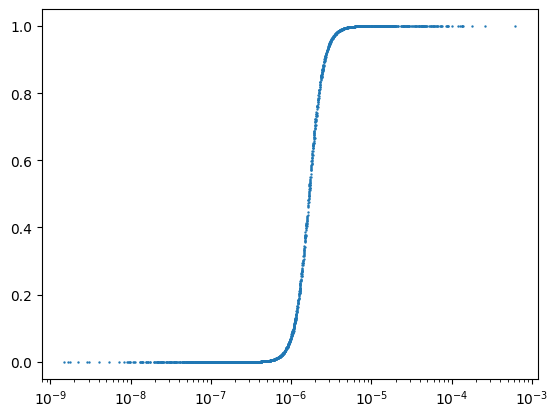

In [8]:
plt.scatter(concs,activity[:,0],s=0.5)
plt.xscale('log')

Text(0, 0.5, '$p_o$')

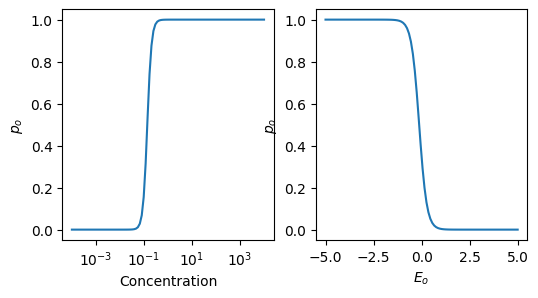

In [ ]:

physics = Receptor(n_units=n_units, k_sub=k_sub)
    
# Define a single homopentamer: [[0, 0, 0, 0, 0]]
receptor_indices = torch.zeros(1, k_sub, dtype=torch.long)
    
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# =========================================================================
# SCENARIO 1: Fixed Energies, Varying Concentration (Dose-Response)
# =========================================================================
# Create 100 concentration points logarithmically spaced
c_batch = torch.logspace(-4, 4, 100) 
batch_size = c_batch.shape[0]
    
# Choose fixed energies. E_closed > E_open makes it a functional receptor.
E_o = energies[...,0]
    
# Create energies tensor. Shape needs to be (Batch, n_units, 2)
# We create a single unit tensor and expand it to match the batch size.
base_energies = torch.tensor([[E_o_fixed, E_c_fixed]]) # (1, 2)
energies_c_varying = base_energies.view(1, 1, 2).expand(batch_size, n_units, 2)

# Run physics
with torch.no_grad():
    activity_c = physics(energies_c_varying, c_batch, receptor_indices).squeeze()

# Plot
axes[0].plot(c_batch.numpy(), activity_c.numpy())
axes[0].set_xscale('log')
axes[0].set_xlabel("Concentration")
axes[0].set_ylabel("$p_o$")

# =========================================================================
# SCENARIO 2: Fixed Concentration, Varying Energy (Affinity Shift)
# =========================================================================
c_fixed = torch.ones(100) * 1.0 # Fixed at c=1.0

# Vary E_open from -5 to +5, keep E_closed fixed at 2.0
E_o_batch = torch.linspace(-5, 5, 100)
E_c_batch = torch.ones(100) * 2.0

# Stack them together -> shape (100, 2)
# Reshape to (Batch, n_units, 2) -> (100, 1, 2)
energies_E_varying = torch.stack([E_o_batch, E_c_batch], dim=-1).unsqueeze(1)

# Run physics
with torch.no_grad():
    activity_E = physics(energies_E_varying, c_fixed, receptor_indices).squeeze()
    
# Plot
axes[1].plot(E_o_batch.numpy(), activity_E.numpy())
axes[1].set_xlabel("$E_o$")
axes[1].set_ylabel("$p_o$")

In [ ]:
# B. Physics
physics = Receptor(n_units, k_sub).to(device)

In [ ]:
# sample
with torch.no_grad():
    # Step 1: Sample
    energies, concs, _ = env.sample_batch(batch_size)
    
    # Step 2: Physics
    activity = physics(energies, concs, receptor_indices)

# ----------------------------------------------------------------
# Convert to numpy
c_data = concs.numpy()

a_data = activity.squeeze().numpy()

Text(0.5, 0, '$\\Delta E$ (kT)')

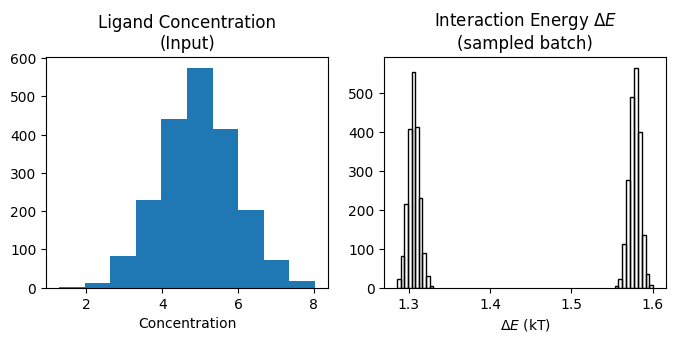

In [ ]:
# Define Receptor: Unit 0 repeated 5 times
receptor_indices = torch.zeros(1, k_sub, dtype=torch.long, device=device)
# C. Loss (to compute entropy)
loss_fn = InformationLoss()

In [ ]:
with torch.no_grad():
    epss = physics.epsilon_units[receptor_indices].sum(dim=1).unsqueeze(0)
    print(physics._compute_p_open(energies,concs,epss))


tensor([3.6766, 4.8903, 6.6807,  ..., 5.8019, 6.6636, 4.5605])
tensor([[nan, nan, nan,  ..., nan, nan, nan]])


In [23]:
print(energies)
#print(env.interaction_log_sigma)


tensor([[[1.3159, 1.5764]],

        [[1.3147, 1.5807]],

        [[1.3067, 1.5745]],

        ...,

        [[1.3218, 1.5717]],

        [[1.3207, 1.5808]],

        [[1.3128, 1.5792]]])


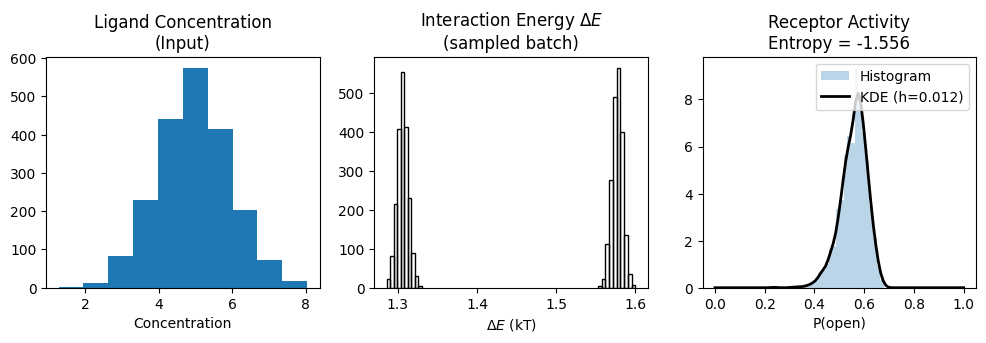

In [ ]:


# Panel C: Activity + KDE Check
axes[2].hist(a_data, bins=30, alpha=0.3, label='Histogram',density=True)

# -- Overlay the actual KDE used by the Loss Function --
# We evaluate the KDE on a grid [0, 1] to see what the optimizer "sees"
x_grid = torch.linspace(0, 1, 100).view(-1, 1) # (100, 1) query points

# Re-compute KDE manually for the grid
# Using the same bandwidth logic as InformationLoss
std = activity.std()
h = 1.06 * std * (batch_size ** (-0.2))
h = max(h.item(), 1e-4) # Safety


density = loss_fn._compute_kde(activity,x_grid)

# Vectorized KDE on grid
# activity shape: (N,) -> (1, N)
# grid shape: (M, 1)
#diffs = x_grid - activity.view(1, -1) # (M, N)
#gaussian = torch.exp(-0.5 * (diffs / h)**2) / (np.sqrt(2 * np.pi))
#density = gaussian.sum(dim=1) / (batch_size * h) # (M,)

axes[2].plot(x_grid.numpy(), density.numpy(), 'k-', lw=2, label=f'KDE (h={h:.3f})')
axes[2].set_title(f"Receptor Activity\nEntropy = {entropy_val:.3f}")
axes[2].set_xlabel("P(open)")
#axes[2].set_xlim(-0.1, 1.1)
axes[2].legend()
#axes[2].set_yscale('log')